# CEP Simulator — Demo Notebook

**Market:** UK  
**Study:** Heineken Beer Category Entry Points (Dynata, Feb 2026, N=1,326)  
**CEPs:** 10 purchase occasions (Q10–Q30 subset)  
**Brands:** Heineken, Guinness, Stella Artois, Budweiser, Corona Extra, Madri, and 17 others  

---

### What this notebook shows

| Section | What it does |
|---------|-------------|
| 1–5 | Load data → reshape → build ontology + memory |
| 6 | Inspect question metadata |
| 7 | Baseline brand recall across all scenarios |
| 8 | Memory map — single respondent |
| 9 | Apply ad exposures (Heineken + Guinness) |
| 10 | Pre/post recall shift |
| 11 | Calibration |

> **Model note:** Scores represent *mental availability* (how accessible a brand is under a cue), not purchase probability or sales volume. See `docs/model_spec.md`.

In [23]:
import sys
sys.path.insert(0, '../../../..')  # project root

import logging
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size']  = 10

logging.basicConfig(level=logging.WARNING, format='%(levelname)s %(name)s - %(message)s')
# Mute verbose INFO from service layer; flip to INFO if you want pipeline details
logging.getLogger('backend').setLevel(logging.WARNING)

## 1. Configuration

Load the UK config. All 21 CEP blocks (Q10–Q30) are included.

In [24]:
from pathlib import Path
from backend.schemas.config import load_cep_sim_config

# Resolve project root from notebook location — works regardless of CWD
PROJECT_ROOT = Path('../../../../').resolve()

config = load_cep_sim_config(PROJECT_ROOT / 'backend/configs/cep_sim_config_uk.toml')

# Config paths are relative to project root — make them absolute so any CWD works
config.survey.zip_path      = str(PROJECT_ROOT / config.survey.zip_path)
config.output.outputs_dir   = str(PROJECT_ROOT / config.output.outputs_dir)
config.output.processed_dir = str(PROJECT_ROOT / config.output.processed_dir)

print(f"Country   : {config.survey.country}")
print(f"CEP blocks: {config.survey.recall.cep_blocks}")
print(f"Outputs   : {config.output.outputs_dir}")

Country   : UK
CEP blocks: ['Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30']
Outputs   : /Users/hasdurra/Projects/pitch-accelerator/outputs/cep_sim/uk


## 2. Load raw survey

In [25]:
from backend.service.load_data import load_survey, inspect_survey

df = load_survey(config)
info = inspect_survey(df, config)

print(f"Respondents : {info['row_count']:,}")
print(f"Recall cols : {info['recall_column_count']}")
print(f"CEP blocks  : {len(info['cep_blocks'])}")

Respondents : 1,326
Recall cols : 504
CEP blocks  : 21


## 3. Reshape wide → long

In [26]:
from backend.service.reshape_survey import reshape_wide_to_long, save_long_survey

long_df = reshape_wide_to_long(df, config)
save_long_survey(long_df, config)

print(f"Rows   : {len(long_df):,}")
print(f"CEPs   : {long_df['cep_description'].nunique()}")
print(f"Brands : {long_df['brand_name'].nunique()}")
print(f"Overall mention rate: {long_df['mentioned'].mean():.1%}")
long_df.head(3)

Rows   : 640,458
CEPs   : 21
Brands : 23
Overall mention rate: 15.3%


,respondent_id,cep_block,cep_description,cep_raw,brand_name,mentioned
0,832413847,Q10,"When you are at a BBQ, which beer brands come ...","When you are at a BBQ, which beer brands come ...",1664 Biere,1
1,832413902,Q10,"When you are at a BBQ, which beer brands come ...","When you are at a BBQ, which beer brands come ...",1664 Biere,0
2,832413946,Q10,"When you are at a BBQ, which beer brands come ...","When you are at a BBQ, which beer brands come ...",1664 Biere,0


## 4. Build CEP ontology

In [27]:
from backend.service.ontology_builder import build_ontology, save_ontology

cep_master_df, raw_map_df = build_ontology(long_df, config)
save_ontology(cep_master_df, raw_map_df, config)

print(f"{len(cep_master_df)} CEPs across {cep_master_df['cep_family'].nunique()} families:")
print(cep_master_df.groupby('cep_family').size().sort_values(ascending=False).to_string())
cep_master_df[['cep_id', 'cep_family', 'cep_label']]

21 CEPs across 8 families:
cep_family
social_occasion    7
on_premise         5
lifestyle          3
functional         2
discovery          1
general            1
outdoor            1
sharing            1


,cep_id,cep_family,cep_label
0,cep_001,lifestyle,"After A Long Day, Which Beer Brands Come To Mind?"
1,cep_002,lifestyle,"Before Heading Out For The Night, Which Beer B..."
2,cep_003,general,"When You Are At A Bbq, Which Beer Brands Come ..."
3,cep_004,on_premise,"When You Are At A Live Music Event Or Gig, Whi..."
4,cep_005,on_premise,"When You Are At A Lively House Party Or Club, ..."
5,cep_006,on_premise,When You Are At A Trendy Bar And Want To Make ...
6,cep_007,sharing,"When You Are Buying Drinks For A Big Group, Wh..."
7,cep_008,social_occasion,"When You Are Celebrating A Special Occasion, (..."
8,cep_009,lifestyle,When You Are Choosing Beers You First Discover...
9,cep_010,on_premise,"When You Are Going Out For A Meal, Which Beer ..."


## 5. Build respondent memory

In [28]:
from backend.service.respondent_builder import (
    build_respondents, build_respondent_brand_cep, save_respondent_tables
)

respondents_df = build_respondents(df, config)
rbc_df = build_respondent_brand_cep(long_df, raw_map_df, config)
save_respondent_tables(respondents_df, rbc_df, config)

brand_name_map = (
    rbc_df[['brand_id', 'brand_name']]
    .drop_duplicates()
    .set_index('brand_id')['brand_name']
    .to_dict()
)
respondent_ids = respondents_df['respondent_id'].astype(str).tolist()

print(f"Respondents  : {len(respondents_df):,}")
print(f"Memory edges : {len(rbc_df):,}")
print(f"Brands       : {rbc_df['brand_name'].nunique()}")
print("\nTop 8 brands by memory edge count:")
print(rbc_df.groupby('brand_name').size().sort_values(ascending=False).head(8).to_string())

Respondents  : 1,326
Memory edges : 97,779
Brands       : 23

Top 8 brands by memory edge count:
brand_name
Heineken                 7877
Guinness                 7142
Corona Extra             6312
Budweiser                6302
Stella Artois            6261
Birra Moretti            5624
Peroni Nastro Azzurro    5568
San Miguel               5204


## Phase 2A — Calibration setup

Deterministic 80/20 respondent split. Brand priors (accessibility baseline) derived from **training data only** to avoid leakage into holdout evaluation.

In [ ]:
from backend.service.calibration import (
    make_holdout_split, compute_brand_priors, compute_cep_brand_priors,
    compute_respondent_responsiveness,
    fit_parameters, run_holdout_validation, build_calibration_report,
)

train_ids, holdout_ids = make_holdout_split(respondent_ids)
print(f"Train: {len(train_ids)} respondents | Holdout: {len(holdout_ids)} respondents")

rbc_train    = rbc_df[rbc_df["respondent_id"].isin(train_ids)].copy()
rbc_holdout  = rbc_df[rbc_df["respondent_id"].isin(holdout_ids)].copy()
long_train   = long_df[long_df["respondent_id"].isin(train_ids)].copy()
long_holdout = long_df[long_df["respondent_id"].isin(holdout_ids)].copy()

# Global brand priors (2A) — kept for fallback
brand_priors = compute_brand_priors(long_train)

# CEP-conditioned priors (2B) — preferred; vary per context
cep_brand_priors = compute_cep_brand_priors(long_train)

# Respondent responsiveness (2B)
responsiveness_map = compute_respondent_responsiveness(rbc_train)

print(f"\nCEP-brand prior entries : {len(cep_brand_priors)}")
print(f"Responsiveness range    : {min(responsiveness_map.values()):.2f} – {max(responsiveness_map.values()):.2f}")
print(f"\nTop 5 brand priors (global):")
for bid, p in sorted(brand_priors.items(), key=lambda x: -x[1])[:5]:
    print(f"  {bid:35s}  {p:.3f}")

## 6. Question metadata

One row per CEP block — shows the full Portuguese question stem and how many brands appeared in each one.

In [29]:
from backend.service.codebook_parser import parse_codebook, save_question_metadata

codebook_df = parse_codebook(config.survey.zip_path, config.survey.codebook_file)
meta_path = save_question_metadata(
    codebook_df,
    config.survey.recall.cep_blocks,
    config.output.outputs_dir,
)

q_meta = pd.read_csv(meta_path)
print(f"Saved to: {meta_path}")
q_meta

Saved to: /Users/hasdurra/Projects/pitch-accelerator/outputs/cep_sim/uk/question_metadata.csv


,q_block,question_stem,n_brands
0,Q10,"When you are at a BBQ, which beer brands come ...",24
1,Q11,When you are hosting friends at home for drink...,24
2,Q12,"When you are watching sport (at home or out), ...",24
3,Q13,When you are spending time outdoors on a hot o...,24
4,Q14,When you are sitting down to a sociable dinner...,24
5,Q15,"When you are at a lively house party or club, ...",24
6,Q16,When you are at a trendy bar and want to make ...,24
7,Q17,"When you are out with co-workers, which beer b...",24
8,Q18,"When you are going out for a meal, which beer ...",24
9,Q19,"Before heading out for the night, which beer b...",24


## 7. Baseline recall

Run 10 demo scenarios across all respondents. Each respondent produces a softmax-normalised probability distribution over brands. We report the mean across respondents.

In [30]:
from backend.service.scenario_library import DEMO_UK_SCENARIOS
from backend.service.validator import run_scenario_recall

scenario_recall_df = run_scenario_recall(
    respondent_ids,
    DEMO_UK_SCENARIOS,
    rbc_df,
    cep_master_df,
    brand_name_map,
    config,
)

print(f"Scenario recall table: {len(scenario_recall_df):,} rows")
print(f"Scenarios : {scenario_recall_df['scenario_name'].nunique()}")
print(f"Brands    : {scenario_recall_df['brand_name'].nunique()}")

Scenario recall table: 304,980 rows
Scenarios : 10
Brands    : 23


In [31]:
# Mean recall probability per brand — averaged across all scenarios
baseline_summary = (
    scenario_recall_df
    .groupby('brand_name')['recall_prob']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'recall_prob': 'mean_recall_prob'})
)
baseline_summary['mean_recall_prob'] = baseline_summary['mean_recall_prob'].round(4)
baseline_summary.head(12)

,brand_name,mean_recall_prob
0,Heineken,0.0514
1,Guinness,0.0508
2,Stella Artois,0.0481
3,Corona Extra,0.0475
4,Budweiser,0.0475
5,Birra Moretti,0.0469
6,Peroni Nastro Azzurro,0.0467
7,Carlsberg,0.0451
8,San Miguel,0.0450
9,Madri,0.0439


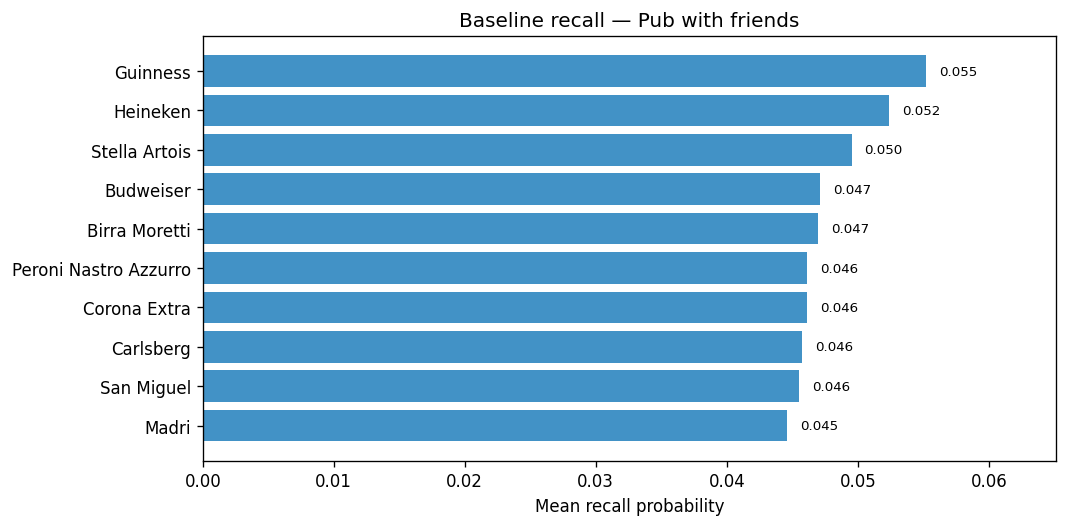

In [32]:
from backend.service.plotting import plot_recall_ranking

fig, ax = plot_recall_ranking(
    scenario_recall_df,
    scenario_name='pub_with_friends',
    top_n=10,
    title='Baseline recall — Pub with friends',
)
plt.show()

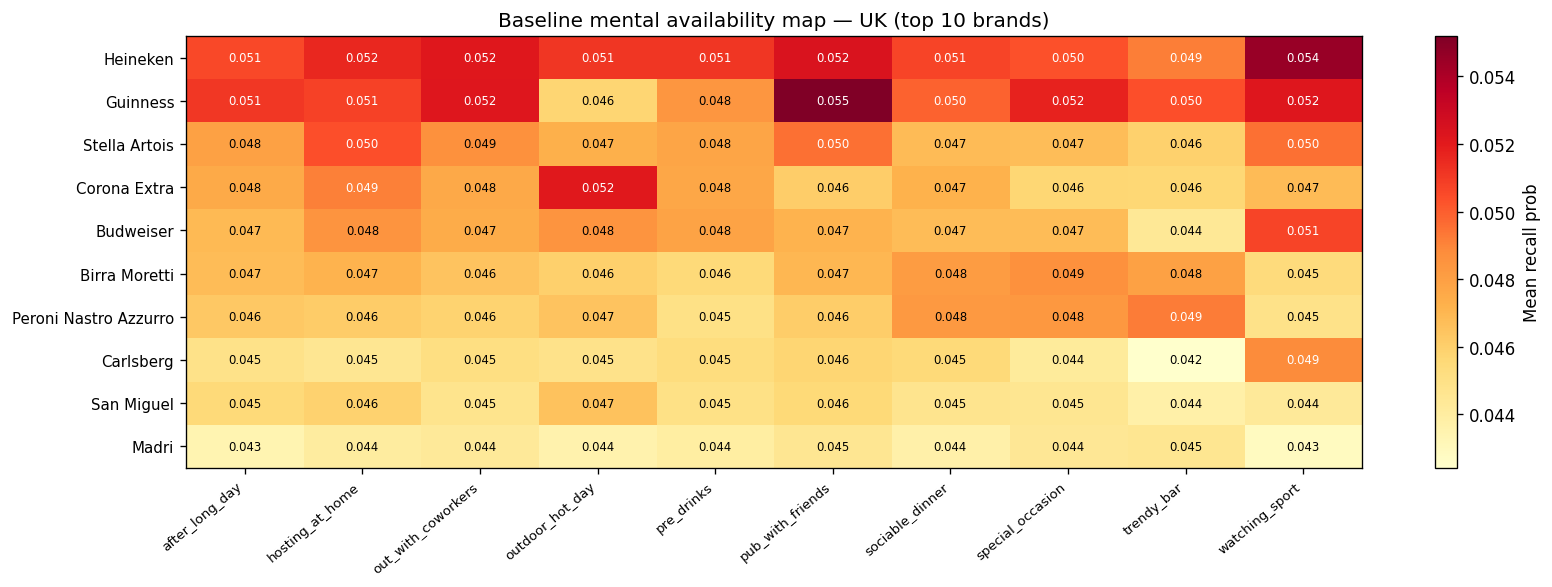

In [33]:
# Brand × scenario recall heatmap (mean recall_prob)
pivot = (
    scenario_recall_df
    .groupby(['brand_name', 'scenario_name'])['recall_prob']
    .mean()
    .unstack('scenario_name')
)

# Keep top 10 brands by average across scenarios
top10 = pivot.mean(axis=1).nlargest(10).index
pivot_top = pivot.loc[top10]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pivot_top.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Mean recall prob')

# Overlay cell values
vmin, vmax = pivot_top.values.min(), pivot_top.values.max()
for i in range(pivot_top.shape[0]):
    for j in range(pivot_top.shape[1]):
        val = pivot_top.values[i, j]
        # Use white text on dark cells, black on light cells
        text_color = 'white' if val > (vmin + vmax) / 2 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=7, color=text_color)

ax.set_xticks(range(pivot_top.shape[1]))
ax.set_xticklabels(pivot_top.columns, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(pivot_top.shape[0]))
ax.set_yticklabels(pivot_top.index, fontsize=9)
ax.set_title('Baseline mental availability map — UK (top 10 brands)')
fig.tight_layout()
plt.show()

## 8. Single-respondent memory map

Visualise one respondent's encoded memory: which brands they associated with which CEPs, and how strongly.

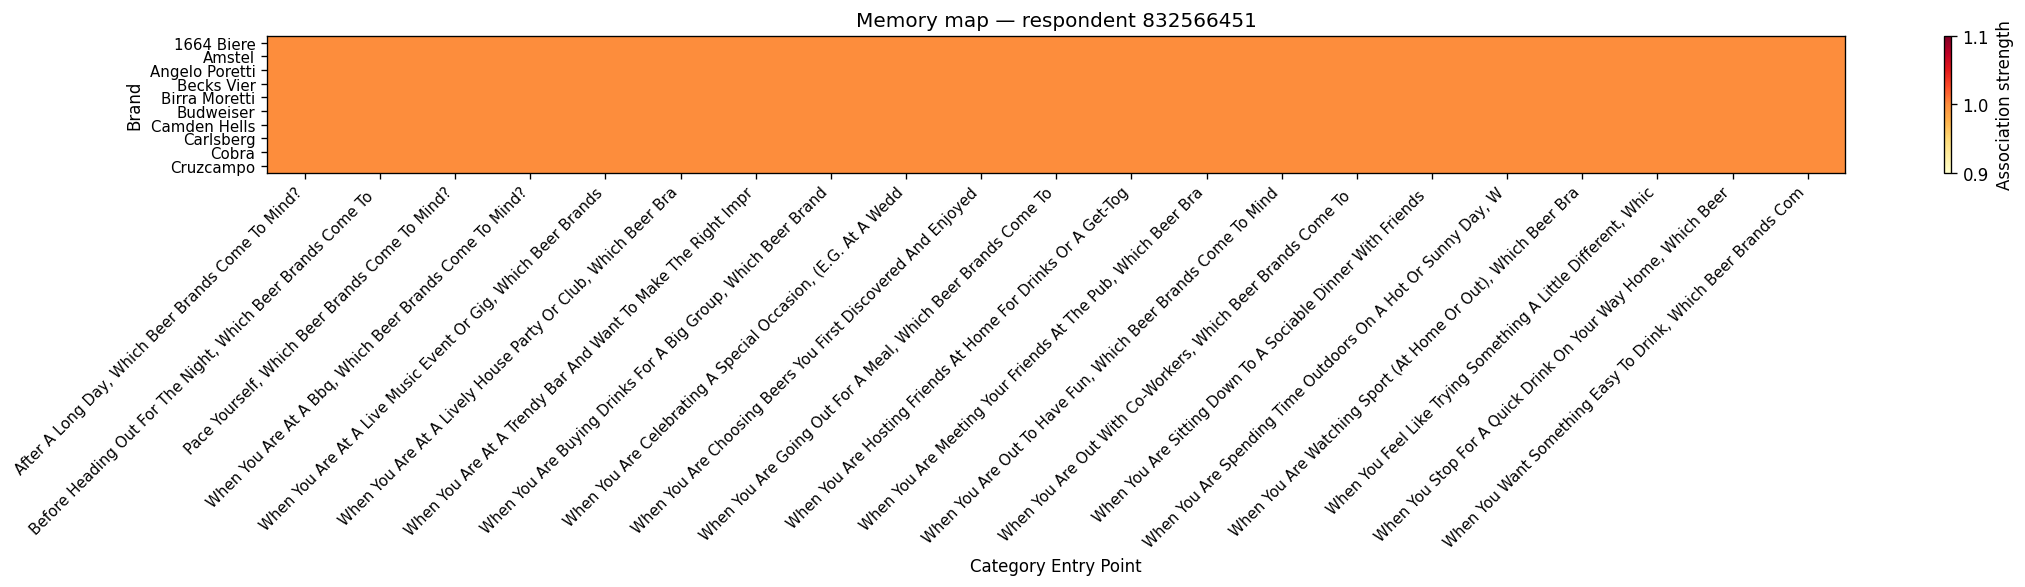

In [34]:
from backend.service.plotting import plot_memory_map

# Pick the respondent with the most memory edges (most informative to plot)
busiest = (
    rbc_df.groupby('respondent_id').size()
    .idxmax()
)

fig, ax = plot_memory_map(
    rbc_df,
    respondent_id=busiest,
    cep_master_df=cep_master_df,
    top_n_brands=10,
    title=f'Memory map — respondent {busiest}',
)
plt.show()

## 9. Ad exposure simulation

We simulate two TV/digital campaigns running simultaneously:

| Brand | Focal CEPs | Secondary CEP |
|-------|-----------|---------------|
| **Heineken** | Pub with friends · Watching sport | Trendy bar |
| **Guinness** | After a long day · Special occasion | Sociable dinner |

The ad engine increases association weights for the advertised brand on the targeted CEPs using the update rule:
```
w_new = w_old + λ · exposure_strength · branding_clarity · cep_fit
```
where `cep_fit = 1.0` (focal) or `0.5` (secondary).

In [35]:
from backend.service.recall_engine import _resolve_cep_ids

def resolve(cep_names: list[str]) -> list[str]:
    """Convenience wrapper: look up cep_ids from substring names."""
    return _resolve_cep_ids(cep_names, cep_master_df)

# Heineken targets
hn_focal     = resolve(['meeting your friends at the pub', 'watching sport'])
hn_secondary = resolve(['trendy bar'])

# Guinness targets
gn_focal     = resolve(['after a long day', 'celebrating a special occasion'])
gn_secondary = resolve(['sociable dinner'])

print("Heineken focal CEPs :", hn_focal)
print("Heineken secondary  :", hn_secondary)
print("Guinness focal CEPs :", gn_focal)
print("Guinness secondary  :", gn_secondary)

Heineken focal CEPs : ['cep_017', 'cep_012']
Heineken secondary  : ['cep_006']
Guinness focal CEPs : ['cep_001', 'cep_008']
Guinness secondary  : ['cep_015']


In [36]:
from backend.service.ad_engine import Ad, apply_ad_to_population, save_episodic_events

# Build brand_id lookup from rbc_df
brand_id_map = (
    rbc_df[['brand_id', 'brand_name']]
    .drop_duplicates()
    .set_index('brand_name')['brand_id']
    .to_dict()
)

heineken_ad = Ad(
    ad_id='ad_heineken_pub_sport_001',
    brand_id=brand_id_map.get('Heineken', 'brand_heineken'),
    brand_name='Heineken',
    focal_ceps=hn_focal,
    secondary_ceps=hn_secondary,
    branding_clarity=0.9,
    attention_weight=1.0,
    channel='digital_video',
    emotion='social_warmth',
)

guinness_ad = Ad(
    ad_id='ad_guinness_evening_occasion_001',
    brand_id=brand_id_map.get('Guinness', 'brand_guinness'),
    brand_name='Guinness',
    focal_ceps=gn_focal,
    secondary_ceps=gn_secondary,
    branding_clarity=0.88,
    attention_weight=1.0,
    channel='tv',
    emotion='depth',
)

print("Heineken ad:", heineken_ad.ad_id)
print("Guinness ad:", guinness_ad.ad_id)

Heineken ad: ad_heineken_pub_sport_001
Guinness ad: ad_guinness_evening_occasion_001


In [ ]:
# Apply Heineken then Guinness — with respondent-specific responsiveness
rbc_post_hn, events_hn = apply_ad_to_population(
    train_ids, heineken_ad, rbc_train, config, responsiveness_map=responsiveness_map
)
rbc_post, events_gn = apply_ad_to_population(
    train_ids, guinness_ad, rbc_post_hn, config, responsiveness_map=responsiveness_map
)

all_events = events_hn + events_gn
save_episodic_events(all_events, config)

delta_edges = len(rbc_post) - len(rbc_train)
print(f"Edges before ads : {len(rbc_train):,}")
print(f"Edges after ads  : {len(rbc_post):,}  (+{delta_edges:,} new)")
print(f"Events logged    : {len(all_events):,}")

## 10. Recall shift — pre vs post

We re-score all scenarios using the post-exposure memory and compare against baseline.

In [38]:
from backend.service.validator import run_ad_impact, build_segment_summary

ad_impact_df = run_ad_impact(
    respondent_ids,
    DEMO_UK_SCENARIOS,
    rbc_df,
    rbc_post,
    cep_master_df,
    brand_name_map,
    config,
)

print(f"Ad impact table: {len(ad_impact_df):,} rows")

Ad impact table: 304,980 rows


In [39]:
# Scenario-level delta summary — top gainers for each of the two focal scenarios
for scenario_of_interest in ['pub_with_friends', 'after_long_day']:
    impact = (
        ad_impact_df[ad_impact_df['scenario_name'] == scenario_of_interest]
        .groupby('brand_name')[['recall_pre', 'recall_post', 'delta']]
        .mean().round(4)
        .sort_values('delta', ascending=False)
        .head(8)
    )
    print(f"\n=== {scenario_of_interest} ===")
    print(impact.to_string())


=== pub_with_friends ===
                       recall_pre  recall_post  delta
brand_name                                           
Heineken                  -0.5772      -0.4872   0.09
1664 Biere                -0.7869      -0.7869   0.00
Desperados                -0.7477      -0.7477   0.00
Staropramen               -0.8125      -0.8125   0.00
Sol                       -0.8065      -0.8065   0.00
San Miguel                -0.6919      -0.6919   0.00
Red Stripe                -0.8336      -0.8336   0.00
Peroni Nastro Azzurro     -0.6866      -0.6866   0.00

=== after_long_day ===
                       recall_pre  recall_post  delta
brand_name                                           
Guinness                  -0.6338      -0.5458  0.088
1664 Biere                -0.7967      -0.7967  0.000
Desperados                -0.7499      -0.7499  0.000
Staropramen               -0.8155      -0.8155  0.000
Sol                       -0.8231      -0.8231  0.000
San Miguel                -0.719

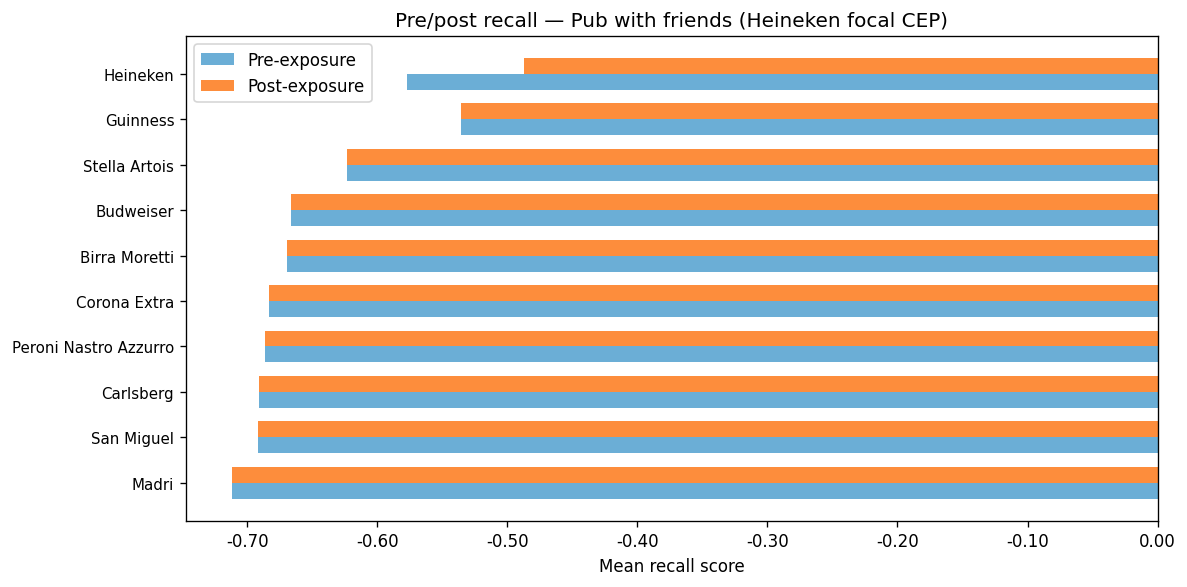

In [40]:
from backend.service.plotting import plot_pre_post_recall

fig, ax = plot_pre_post_recall(
    ad_impact_df,
    scenario_name='pub_with_friends',
    top_n=10,
    title='Pre/post recall — Pub with friends (Heineken focal CEP)',
)
plt.show()

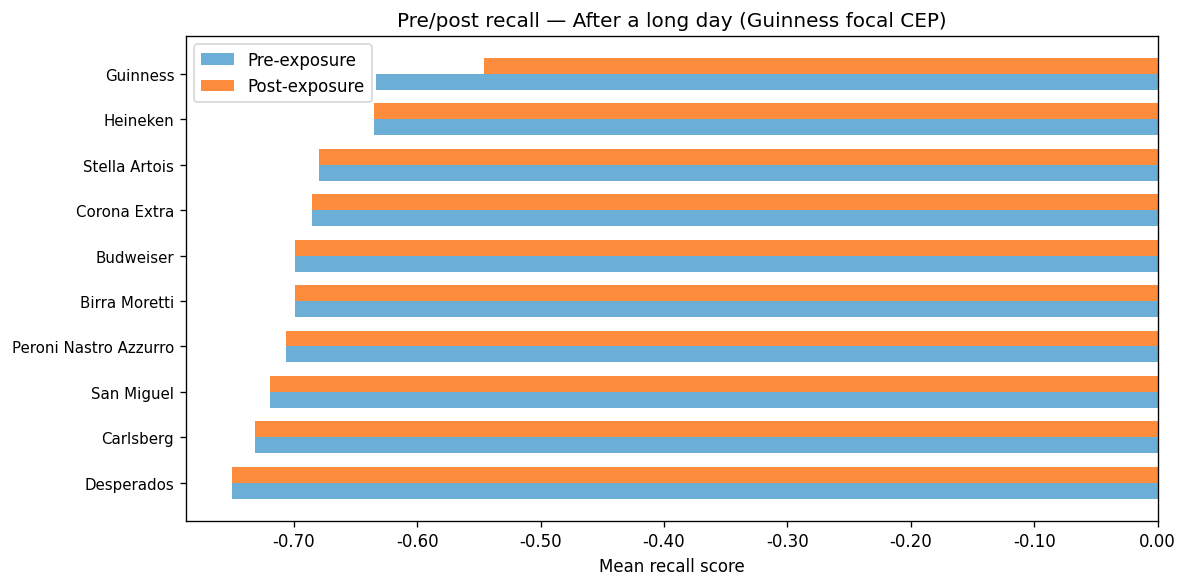

In [41]:
fig, ax = plot_pre_post_recall(
    ad_impact_df,
    scenario_name='after_long_day',
    top_n=10,
    title='Pre/post recall — After a long day (Guinness focal CEP)',
)
plt.show()

In [42]:
# Segment breakdown — show how recall shift differs by demographic group
segment_summary_df = build_segment_summary(ad_impact_df, respondents_df)

seg_view = (
    segment_summary_df[
        (segment_summary_df['scenario_name'] == 'pub_with_friends') &
        (segment_summary_df['brand_name'].isin(['Heineken', 'Guinness', 'Stella Artois']))
    ]
    .sort_values(['brand_name', 'avg_delta'], ascending=[True, False])
)
print("Segment recall shift — Pub with friends")
seg_view[['segment', 'brand_name', 'avg_recall_pre', 'avg_recall_post', 'avg_delta']]

Segment recall shift — Pub with friends


,segment,brand_name,avg_recall_pre,avg_recall_post,avg_delta
129,female_18-24,Guinness,-0.542857,-0.542857,0.00
359,female_25-34,Guinness,-0.390385,-0.390385,0.00
589,female_35-44,Guinness,-0.599029,-0.599029,0.00
819,female_45-54,Guinness,-0.738384,-0.738384,0.00
1049,female_55+,Guinness,-0.669231,-0.669231,0.00
1279,male_18-24,Guinness,-0.425547,-0.425547,0.00
1509,male_25-34,Guinness,-0.458219,-0.458219,0.00
1739,male_35-44,Guinness,-0.544330,-0.544330,0.00
1969,male_45-54,Guinness,-0.611765,-0.611765,0.00
2199,male_55+,Guinness,-0.546552,-0.546552,0.00


## 11. Calibration

How well do predicted recall probabilities align with observed survey mention rates?

> **Expected gap:** Softmax over 20+ brands pushes predicted probabilities toward 1/N (~4–5%), while observed mention rates range from 5–60%. MAE is typically 0.10–0.15. This is a known limitation; the model is calibrated for *relative* brand ranking, not absolute probability levels. See `docs/model_spec.md §4.3`.

In [ ]:
from backend.service.validator import run_calibration_check

# Re-run scenario recall with tuned temperature before calibration check
scenario_recall_tuned = run_scenario_recall(
    respondent_ids, DEMO_UK_SCENARIOS, rbc_df, cep_master_df, brand_name_map, config
)

cal_df = run_calibration_check(scenario_recall_tuned, long_df)
print(f"MAE (T={config.defaults.softmax_temperature}) = {cal_df.attrs['mae']:.4f}")
cal_df

### Temperature tuning

Grid-search over softmax temperatures to find the value that minimises MAE against observed mention rates. Lower temperature sharpens the predicted distribution; the default T=1.0 is typically too flat for 20+ brands.

In [ ]:
from backend.service.calibration import tune_softmax_temperature

best_temp, temp_results = tune_softmax_temperature(
    long_df, rbc_df, cep_master_df, DEMO_UK_SCENARIOS, config
)

print(f"Best temperature : {best_temp}")
print(f"Baseline T=1.0   : MAE = {temp_results.loc[temp_results['temperature']==1.0,'mae'].values[0]:.4f}")
print(f"Best MAE         : {temp_results['mae'].min():.4f}")
temp_results

In [ ]:
# Plot MAE vs temperature
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(temp_results['temperature'], temp_results['mae'], marker='o', color='#2171b5')
ax.axvline(best_temp, color='coral', linestyle='--', label=f'Best T={best_temp}')
ax.axvline(1.0, color='grey', linestyle=':', label='Default T=1.0')
ax.set_xlabel('Softmax temperature')
ax.set_ylabel('MAE (predicted vs observed mention rate)')
ax.set_title('Temperature grid search — UK')
ax.legend()
fig.tight_layout()
plt.show()

# Apply best temperature to config for remaining cells
config.defaults.softmax_temperature = best_temp
print(f"Config updated: softmax_temperature = {config.defaults.softmax_temperature}")

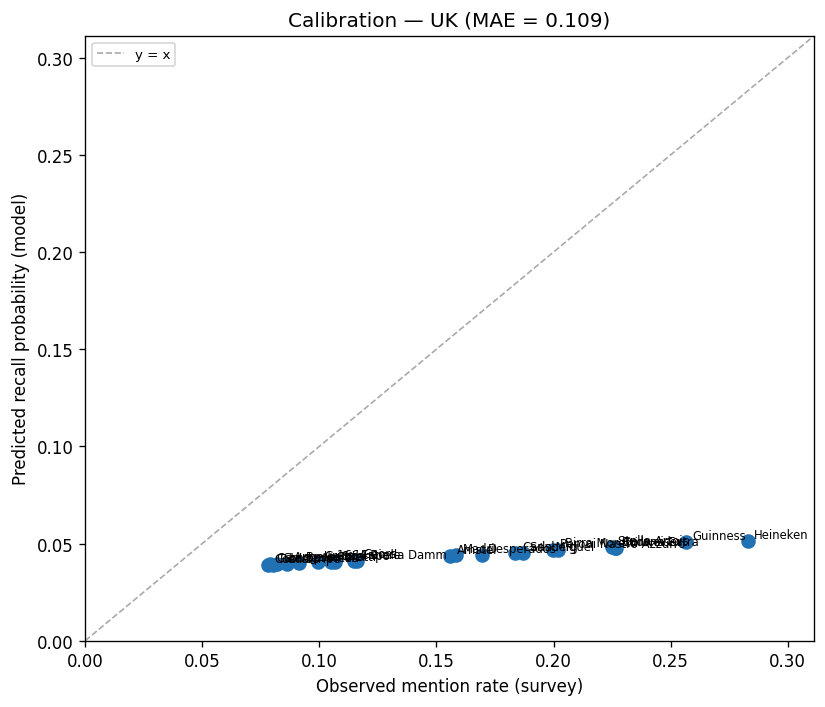

In [44]:
from backend.service.plotting import plot_calibration

fig, ax = plot_calibration(
    cal_df,
    title=f'Calibration — UK (MAE = {cal_df.attrs["mae"]:.3f})',
)
plt.show()

### Fit β, γ, τ jointly

Grid search over competition weight (γ), temperature (τ), and brand-prior scalar (β_scale) on training data only. Brand-specific priors make γ meaningful — brands with higher baseline awareness get a higher prior, and γ controls how much competing brands suppress each other.

In [ ]:
fitted = fit_parameters(
    long_train, rbc_train, cep_master_df, DEMO_UK_SCENARIOS, config,
    brand_priors=brand_priors,
    cep_brand_priors=cep_brand_priors,
)

print(f"Best τ={fitted['tau']}  γ={fitted['gamma']}  β_scale={fitted['prior_weight']}")
print(f"Train MAE: {fitted['mae']:.4f}")
fitted['grid_results'].head(10)

In [ ]:
# Apply tuned params to config
config.defaults.softmax_temperature        = fitted["tau"]
config.defaults.competition_penalty_weight = fitted["gamma"]
config.defaults.base_prior_weight          = fitted["prior_weight"]
print("Config updated with fitted parameters.")

### Hold-out validation

Evaluate calibration and Spearman rank correlation on the 20% held-out respondents. Parameters were fit on training data only — this is the first out-of-sample test.

In [ ]:
holdout_results = run_holdout_validation(
    holdout_ids, long_holdout, rbc_holdout, cep_master_df,
    DEMO_UK_SCENARIOS, config, brand_priors,
    cep_brand_priors=cep_brand_priors,
)

print(f"Holdout MAE   : {holdout_results['mae']:.4f}")
print(f"Holdout mean ρ: {holdout_results['mean_rho']:.4f}")
holdout_results["cal_df"]

In [ ]:
print("Spearman ρ by scenario (holdout):")
holdout_results["spearman_df"]

### Calibration report

In [ ]:
# Train results (re-evaluate with tuned params)
train_results = run_holdout_validation(
    train_ids, long_train, rbc_train, cep_master_df,
    DEMO_UK_SCENARIOS, config, brand_priors,
)

report_md = build_calibration_report(
    train_results, holdout_results, fitted, config,
    n_train=len(train_ids), n_holdout=len(holdout_ids),
)

# Save to outputs dir
from pathlib import Path
report_path = Path(config.output.outputs_dir) / "calibration_report.md"
report_path.parent.mkdir(parents=True, exist_ok=True)
report_path.write_text(report_md)
print(f"Saved: {report_path}")
print()
print(report_md)

## Phase 2B — Scenario diagnostics

Per-scenario breakdown of calibration error and construct validity. Scenarios with Spearman ρ < 0.2 (red bars) should be reviewed — they indicate the model's CEP mapping may be misspecified for that context.

In [ ]:
from backend.service.validator import run_scenario_diagnostics
from backend.service.plotting import plot_scenario_diagnostics

# Re-run scenario recall on holdout with tuned params + CEP priors
scenario_recall_holdout = holdout_results["recall_df"]
diag_df = run_scenario_diagnostics(scenario_recall_holdout, long_holdout)
diag_df

In [ ]:
fig, axes = plot_scenario_diagnostics(
    diag_df, title=f"Scenario diagnostics — UK holdout (MAE target <5pp)"
)
plt.show()

In [ ]:
# Responsiveness distribution — show how heterogeneous respondents are
resp_series = pd.Series(responsiveness_map, name="responsiveness")
fig, ax = plt.subplots(figsize=(7, 3))
resp_series.hist(bins=30, ax=ax, color="#2171b5", edgecolor="white")
ax.axvline(1.0, color="red", linestyle="--", label="baseline (1.0)")
ax.set_xlabel("Responsiveness multiplier")
ax.set_ylabel("Respondents")
ax.set_title("Respondent ad responsiveness distribution (repertoire method)")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Respondents with responsiveness > 1.5 (high): {(resp_series > 1.5).sum()}")
print(f"Respondents with responsiveness < 0.7 (low) : {(resp_series < 0.7).sum()}")

### Construct validity — Spearman rank correlation

Does the model rank brands in the same order as the observed data? Spearman ρ is computed per scenario between mean predicted recall probability and observed mention rate.

In [ ]:
from backend.service.validator import run_spearman_validity, check_brand_deduplication

spearman_df = run_spearman_validity(scenario_recall_tuned, long_df)
mean_rho = spearman_df.attrs['mean_rho']
print(f"Mean Spearman ρ across scenarios: {mean_rho:.4f}")
print("  ρ > 0.6 = strong  |  0.3–0.6 = moderate  |  < 0.3 = weak")
spearman_df

In [ ]:
# Brand deduplication check
dedup_df = check_brand_deduplication(rbc_df)
if dedup_df.empty:
    print("No near-duplicate brand names detected.")
else:
    print(f"{len(dedup_df)} suspect pair(s):")
    display(dedup_df)

## Export outputs

In [45]:
from backend.service.validator import save_outputs, run_sanity_checks

paths = save_outputs(scenario_recall_df, ad_impact_df, segment_summary_df, config)
for name, path in paths.items():
    print(f"  {name}: {path}")

print("\n=== Sanity checks ===")
for k, v in run_sanity_checks(scenario_recall_df, ad_impact_df).items():
    status = '✓' if v == 'PASS' else '!'
    print(f"  [{status}] {k}: {v}")

  scenario_recall_output: /Users/hasdurra/Projects/pitch-accelerator/outputs/cep_sim/uk/scenario_recall_output.csv
  ad_impact_output: /Users/hasdurra/Projects/pitch-accelerator/outputs/cep_sim/uk/ad_impact_output.csv
  segment_summary: /Users/hasdurra/Projects/pitch-accelerator/outputs/cep_sim/uk/segment_summary.csv

=== Sanity checks ===
  [✓] cue_relevance: PASS
  [✓] respondent_heterogeneity: PASS
  [✓] ad_lift: PASS
  [✓] competition_realism: PASS
